# Spec-S5 Mock Observations Demo

This notebook demonstrates the full mock-observation pipeline:

1. Simulate a halo stellar population in Galactocentric coordinates
2. `galactocentric_to_observed` — convert to on-sky observables (RA, Dec, distance, vrad, pm, z)
3. `observe_with_spec5` — apply Spec-S5 measurement errors to produce mock observations

Stars are old, metal-poor RGB giants drawn from a smooth spherical halo at 20–100 kpc.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

from spec5.instrument.mock_observations import galactocentric_to_observed, observe_with_spec5

## 1. Simulate a halo stellar population

We draw 500 RGB giants uniformly in a spherical shell at Galactocentric radii 20–100 kpc,
with random velocities consistent with a hot stellar halo (dispersion ~100 km/s, mean rotation ~50 km/s).
Luminosities are log-normally distributed around 50 L_sun, typical for lower RGB stars.

In [2]:
rng = np.random.default_rng(42)
n = 500

# Positions: uniform in spherical shell, 20–100 kpc
r     = rng.uniform(20, 100, n)
theta = np.arccos(rng.uniform(-1, 1, n))   # polar angle
phi   = rng.uniform(0, 2 * np.pi, n)       # azimuthal angle
x =  r * np.sin(theta) * np.cos(phi)
y =  r * np.sin(theta) * np.sin(phi)
z =  r * np.cos(theta)

# Velocities: isotropic dispersion + mild prograde rotation
vx = rng.normal(  0, 100, n)
vy = rng.normal( 50, 100, n)
vz = rng.normal(  0, 100, n)

# Luminosities: log-normal around 50 L_sun
lum = np.exp(rng.normal(np.log(50), 0.5, n))

dtype = [('x','f8'), ('y','f8'), ('z','f8'),
         ('vx','f8'), ('vy','f8'), ('vz','f8'),
         ('luminosity','f8')]
stars = np.array(list(zip(x, y, z, vx, vy, vz, lum)), dtype=dtype)

print(f'Simulated {n} RGB giants')
print(f'Galactocentric radius: {r.min():.1f} – {r.max():.1f} kpc')
print(f'Luminosity: {lum.min():.1f} – {lum.max():.1f} L_sun')

Simulated 500 RGB giants
Galactocentric radius: 20.4 – 99.9 kpc
Luminosity: 12.6 – 234.2 L_sun


## 2. Convert to on-sky observables

In [3]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    obs = galactocentric_to_observed(stars, star_type='giant')

print(f'Heliocentric distance: {obs["distance"].min():.1f} – {obs["distance"].max():.1f} kpc')
print(f'LSST z magnitude:      {obs["lsst_z"].min():.2f} – {obs["lsst_z"].max():.2f}')
print(f'Radial velocity:       {obs["vrad"].min():.1f} – {obs["vrad"].max():.1f} km/s')

Heliocentric distance: 13.1 – 106.6 kpc
LSST z magnitude:      14.37 – 21.02
Radial velocity:       -436.2 – 492.9 km/s


## 3. Apply Spec-S5 measurement errors

In [4]:
RV_SYS_FLOOR_SPEC5 = 0.6  # km/s — matches existing default in observe_with_spec5

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    mock = observe_with_spec5(obs, star_type='giant', pm_model='gaia_dr5',
                              vrad_sys=RV_SYS_FLOOR_SPEC5, seed=42)

print(f'vrad_err:      {mock["vrad_err"].min():.2f} – {mock["vrad_err"].max():.2f} km/s')
print(f'pm_err:        {np.nanmin(mock["pm_err"]):.4f} – {np.nanmax(mock["pm_err"]):.4f} mas/yr')
print(f'dist_err_frac: {mock["dist_err_frac"].min():.3f} – {mock["dist_err_frac"].max():.3f}')
print(f'NaN pm_err (G > 20.7): {np.sum(np.isnan(mock["pm_err"]))}')


vrad_err:      0.60 – 2.75 km/s
pm_err:        0.0038 – 0.1575 mas/yr
dist_err_frac: 0.056 – 0.557
NaN pm_err (G > 20.7): 8


### Note: `vrad_sys` parameter in `observe_with_spec5`

The existing `vrad_sys` parameter (default 0.6 km/s) is now passed explicitly via `RV_SYS_FLOOR_SPEC5` above, making it easy to vary for sensitivity studies. No changes to the package are required.


## Sky distribution

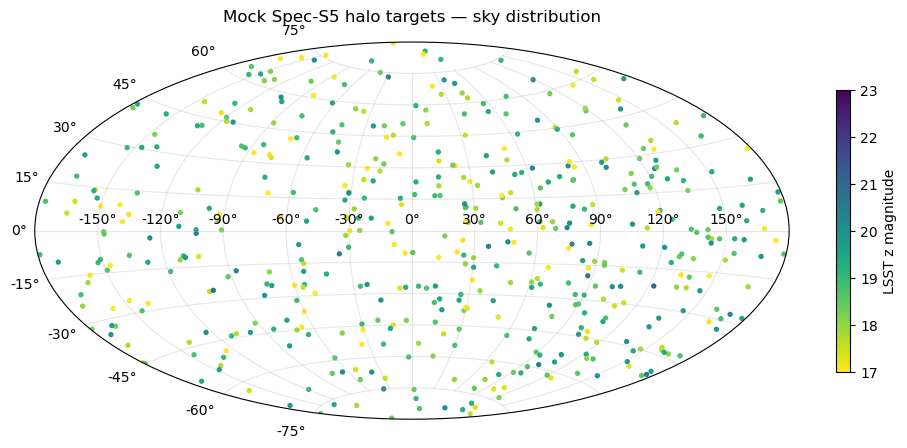

In [5]:
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': 'aitoff'})

ra_rad  = np.deg2rad(obs['ra'] - 180)   # centre on RA=180
dec_rad = np.deg2rad(obs['dec'])

sc = ax.scatter(ra_rad, dec_rad, c=obs['lsst_z'], s=8,
                cmap='viridis_r', vmin=17, vmax=23)
plt.colorbar(sc, ax=ax, label='LSST z magnitude', shrink=0.6)
ax.set_title('Mock Spec-S5 halo targets — sky distribution', pad=15)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Measurement errors vs LSST z magnitude

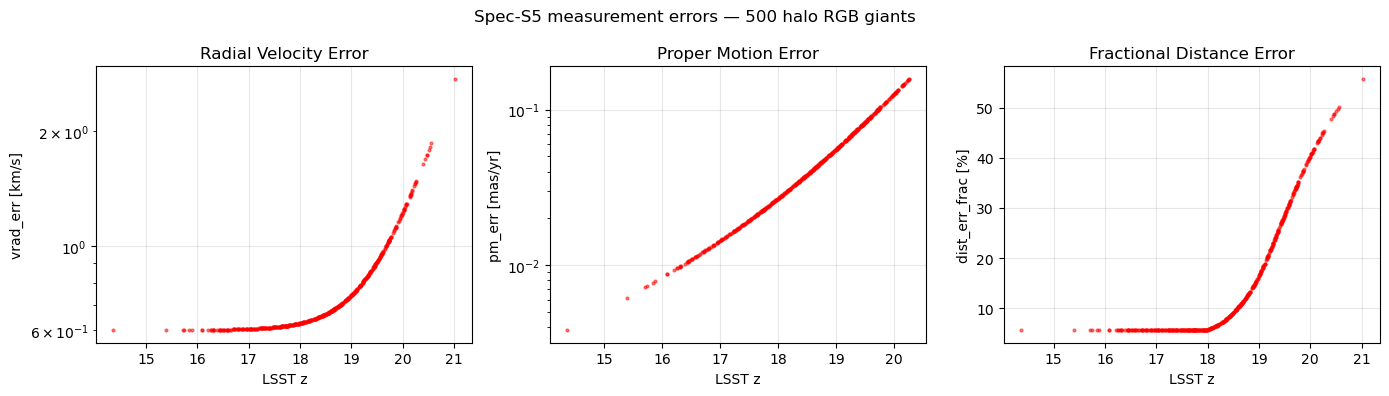

In [6]:
z = obs['lsst_z']
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].semilogy(z, mock['vrad_err'], '.r', alpha=0.5, ms=4)
axs[0].set(xlabel='LSST z', ylabel='vrad_err [km/s]', title='Radial Velocity Error')
axs[0].grid(alpha=0.3)

axs[1].semilogy(z, mock['pm_err'], '.r', alpha=0.5, ms=4)
axs[1].set(xlabel='LSST z', ylabel='pm_err [mas/yr]', title='Proper Motion Error')
axs[1].grid(alpha=0.3)

axs[2].plot(z, mock['dist_err_frac'] * 100, '.r', alpha=0.5, ms=4)
axs[2].set(xlabel='LSST z', ylabel='dist_err_frac [%]', title='Fractional Distance Error')
axs[2].grid(alpha=0.3)

plt.suptitle('Spec-S5 measurement errors — 500 halo RGB giants')
plt.tight_layout()
plt.show()


## True vs observed: radial velocity

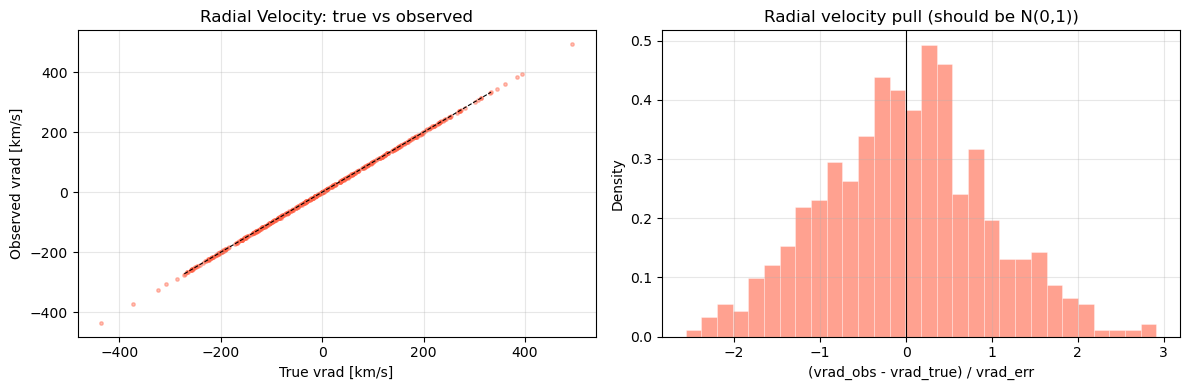

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].scatter(obs['vrad'], mock['vrad_obs'], s=6, alpha=0.4, color='tomato')
lim = np.percentile(obs['vrad'], [1, 99])
axs[0].plot(lim, lim, 'k--', lw=0.8)
axs[0].set(xlabel='True vrad [km/s]', ylabel='Observed vrad [km/s]',
           title='Radial Velocity: true vs observed')
axs[0].grid(alpha=0.3)

pull = (mock['vrad_obs'] - obs['vrad']) / mock['vrad_err']
axs[1].hist(pull[np.isfinite(pull)], bins=30, color='tomato', alpha=0.6,
            density=True, edgecolor='white', linewidth=0.4)
axs[1].axvline(0, color='k', lw=0.8)
axs[1].set(xlabel='(vrad_obs - vrad_true) / vrad_err', ylabel='Density',
           title='Radial velocity pull (should be N(0,1))')
axs[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## True vs observed: proper motion

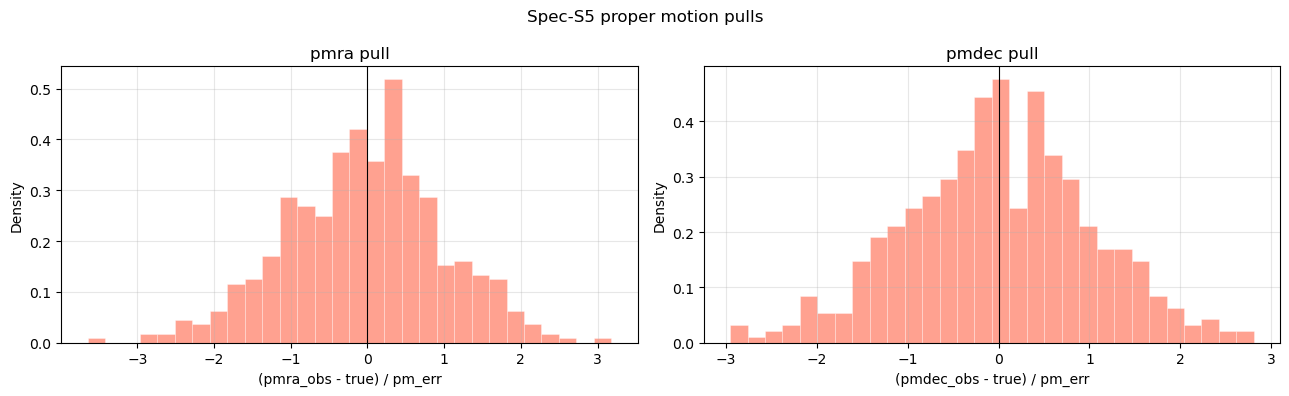

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))

for ax, true_col, obs_key, col_label in [
    (axs[0], obs['pmra'],  'pmra_obs',  'pmra'),
    (axs[1], obs['pmdec'], 'pmdec_obs', 'pmdec'),
]:
    pull = (mock[obs_key] - true_col) / mock['pm_err']
    finite = np.isfinite(pull)
    ax.hist(pull[finite], bins=30, color='tomato', alpha=0.6,
            density=True, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='k', lw=0.8)
    ax.set(xlabel=f'({col_label}_obs - true) / pm_err', ylabel='Density',
           title=f'{col_label} pull')
    ax.grid(alpha=0.3)

plt.suptitle('Spec-S5 proper motion pulls')
plt.tight_layout()
plt.show()


## True vs observed: heliocentric distance

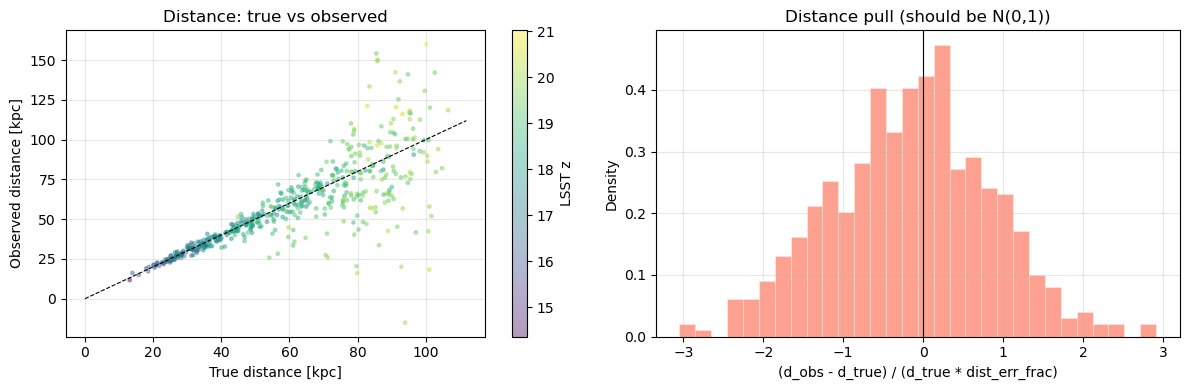

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

sc = axs[0].scatter(obs['distance'], mock['distance_obs'],
                    s=6, alpha=0.4, c=obs['lsst_z'], cmap='viridis')
plt.colorbar(sc, ax=axs[0], label='LSST z')
lim = [0, obs['distance'].max() * 1.05]
axs[0].plot(lim, lim, 'k--', lw=0.8)
axs[0].set(xlabel='True distance [kpc]', ylabel='Observed distance [kpc]',
           title='Distance: true vs observed')
axs[0].grid(alpha=0.3)

pull = ((mock['distance_obs'] - obs['distance'])
        / (obs['distance'] * mock['dist_err_frac']))
axs[1].hist(pull[np.isfinite(pull)], bins=30, color='tomato', alpha=0.6,
            density=True, edgecolor='white', linewidth=0.4)
axs[1].axvline(0, color='k', lw=0.8)
axs[1].set(xlabel='(d_obs - d_true) / (d_true * dist_err_frac)', ylabel='Density',
           title='Distance pull (should be N(0,1))')
axs[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## DESI instrument model

`observe_with_desi` is defined in `spec5/instrument/mock_observations.py` alongside `observe_with_spec5`. It shares the same call signature; the key difference is an internal +0.876 mag penalty on `lsst_z` to account for DESI's 4-m mirror (vs. 6-m for Spec-S5), and a default `vrad_sys=0.9` km/s (Koposov et al. 2024 EDR MWS VAC) vs. 0.6 km/s for Spec-S5.

In [10]:
from spec5.instrument.mock_observations import observe_with_desi


In [11]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    desi = observe_with_desi(obs, star_type='giant', pm_model='gaia_dr5', seed=99)

print(f"{'':20s} {'Spec-S5':>12s} {'DESI':>12s}")
print(f"{'RV floor (km/s)':20s} {RV_SYS_FLOOR_SPEC5:>12.1f} {'0.9':>12s}")
print(f"{'vrad_err min':20s} {mock['vrad_err'].min():>12.2f} {desi['vrad_err'].min():>12.2f}")
print(f"{'vrad_err max':20s} {mock['vrad_err'].max():>12.2f} {desi['vrad_err'].max():>12.2f}")
print(f"{'dist_err_frac min':20s} {mock['dist_err_frac'].min():>12.3f} {desi['dist_err_frac'].min():>12.3f}")
print(f"{'dist_err_frac max':20s} {mock['dist_err_frac'].max():>12.3f} {desi['dist_err_frac'].max():>12.3f}")
print(f"{'NaN pm_err':20s} {np.sum(np.isnan(mock['pm_err'])):>12d} {np.sum(np.isnan(desi['pm_err'])):>12d}")


                          Spec-S5         DESI
RV floor (km/s)               0.6          0.9
vrad_err min                 0.60         0.90
vrad_err max                 2.75         6.54
dist_err_frac min           0.056        0.056
dist_err_frac max           0.557        0.624
NaN pm_err                      8            8


## Optimistic RV systematic floor: Spec-S5 and DESI with `vrad_sys=0.3` km/s

For comparison we re-run both instruments with an optimistic systematic floor of 0.3 km/s, representing a potential future improvement in wavelength calibration. The default floors are 0.6 km/s (Spec-S5) and 0.9 km/s (DESI).

In [12]:
RV_SYS_OPTIMISTIC = 0.3  # km/s

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    mock_opt = observe_with_spec5(obs, star_type='giant', pm_model='gaia_dr5',
                                  vrad_sys=RV_SYS_OPTIMISTIC, seed=42)
    desi_opt = observe_with_desi(obs,  star_type='giant', pm_model='gaia_dr5',
                                  vrad_sys=RV_SYS_OPTIMISTIC, seed=99)

print(f"{'':25s} {'Spec-S5 (0.6)':>14s} {'Spec-S5 (0.3)':>14s} {'DESI (0.9)':>12s} {'DESI (0.3)':>12s}")
print(f"{'vrad_err min [km/s]':25s} {mock['vrad_err'].min():>14.2f} {mock_opt['vrad_err'].min():>14.2f} {desi['vrad_err'].min():>12.2f} {desi_opt['vrad_err'].min():>12.2f}")
print(f"{'vrad_err max [km/s]':25s} {mock['vrad_err'].max():>14.2f} {mock_opt['vrad_err'].max():>14.2f} {desi['vrad_err'].max():>12.2f} {desi_opt['vrad_err'].max():>12.2f}")


                           Spec-S5 (0.6)  Spec-S5 (0.3)   DESI (0.9)   DESI (0.3)
vrad_err min [km/s]                 0.60           0.30         0.90         0.30
vrad_err max [km/s]                 2.75           2.70         6.54         6.48


In [13]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    desi = observe_with_desi(obs, star_type='giant', pm_model='gaia_dr5', seed=99)

print(f"DESI  vrad_err:      {desi['vrad_err'].min():.2f} – {desi['vrad_err'].max():.2f} km/s")
print(f"Spec-S5 vrad_err:   {mock['vrad_err'].min():.2f} – {mock['vrad_err'].max():.2f} km/s")
print(f"DESI  dist_err_frac: {desi['dist_err_frac'].min():.3f} – {desi['dist_err_frac'].max():.3f}")
print(f"DESI  NaN pm_err (G > 20.7): {np.sum(np.isnan(desi['pm_err']))}")


DESI  vrad_err:      0.90 – 6.54 km/s
Spec-S5 vrad_err:   0.60 – 2.75 km/s
DESI  dist_err_frac: 0.056 – 0.624
DESI  NaN pm_err (G > 20.7): 8


## Comparison: measurement errors vs LSST z magnitude

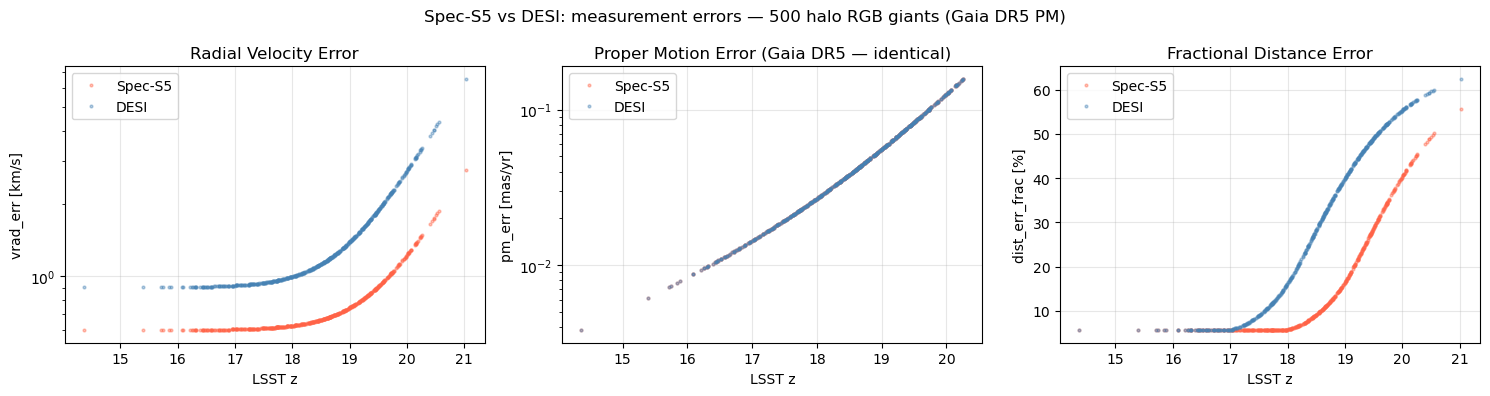

In [14]:
z = obs['lsst_z']
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# Radial velocity
axs[0].semilogy(z, mock['vrad_err'], '.', color='tomato',    alpha=0.4, ms=4, label='Spec-S5')
axs[0].semilogy(z, desi['vrad_err'], '.', color='steelblue', alpha=0.4, ms=4, label='DESI')
axs[0].set(xlabel='LSST z', ylabel='vrad_err [km/s]', title='Radial Velocity Error')
axs[0].legend(); axs[0].grid(alpha=0.3)

# Proper motion (identical — same Gaia DR5 model)
axs[1].semilogy(z, mock['pm_err'], '.', color='tomato',    alpha=0.4, ms=4, label='Spec-S5')
axs[1].semilogy(z, desi['pm_err'], '.', color='steelblue', alpha=0.4, ms=4, label='DESI')
axs[1].set(xlabel='LSST z', ylabel='pm_err [mas/yr]', title='Proper Motion Error (Gaia DR5 — identical)')
axs[1].legend(); axs[1].grid(alpha=0.3)

# Distance
axs[2].plot(z, mock['dist_err_frac'] * 100, '.', color='tomato',    alpha=0.4, ms=4, label='Spec-S5')
axs[2].plot(z, desi['dist_err_frac'] * 100, '.', color='steelblue', alpha=0.4, ms=4, label='DESI')
axs[2].set(xlabel='LSST z', ylabel='dist_err_frac [%]', title='Fractional Distance Error')
axs[2].legend(); axs[2].grid(alpha=0.3)

plt.suptitle('Spec-S5 vs DESI: measurement errors — 500 halo RGB giants (Gaia DR5 PM)')
plt.tight_layout()
plt.show()


## Comparison: radial velocity — true vs observed

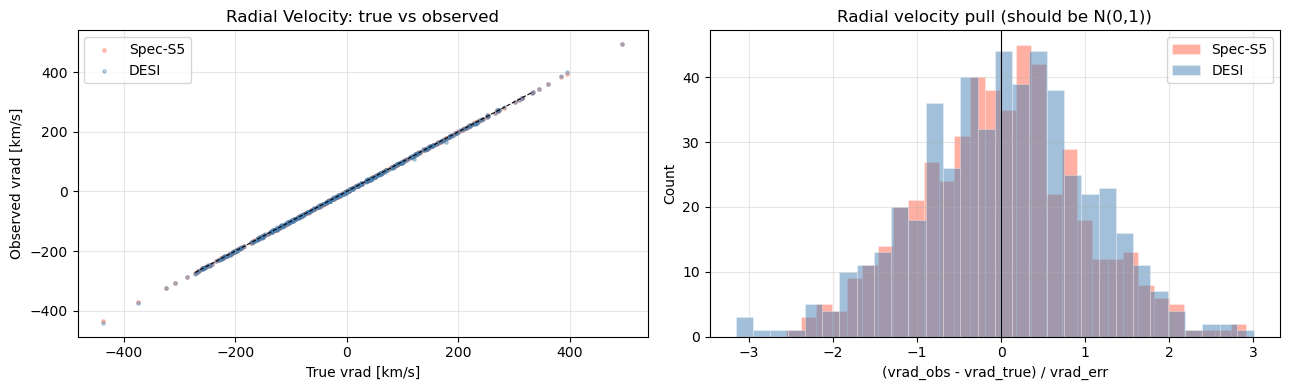

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))

for mock_data, label, color in [
    (mock, 'Spec-S5', 'tomato'),
    (desi,  'DESI',   'steelblue'),
]:
    axs[0].scatter(obs['vrad'], mock_data['vrad_obs'],
                   s=6, alpha=0.35, color=color, label=label)

lim = np.percentile(obs['vrad'], [1, 99])
axs[0].plot(lim, lim, 'k--', lw=0.8)
axs[0].set(xlabel='True vrad [km/s]', ylabel='Observed vrad [km/s]',
           title='Radial Velocity: true vs observed')
axs[0].legend(); axs[0].grid(alpha=0.3)

for mock_data, label, color in [
    (mock, 'Spec-S5', 'tomato'),
    (desi,  'DESI',   'steelblue'),
]:
    pull = (mock_data['vrad_obs'] - obs['vrad']) / mock_data['vrad_err']
    axs[1].hist(pull, bins=30, alpha=0.5, color=color, label=label,
                edgecolor='white', linewidth=0.4)

axs[1].axvline(0, color='k', lw=0.8)
axs[1].set(xlabel='(vrad_obs - vrad_true) / vrad_err', ylabel='Count',
           title='Radial velocity pull (should be N(0,1))')
axs[1].legend(); axs[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Comparison: proper motion pull distributions

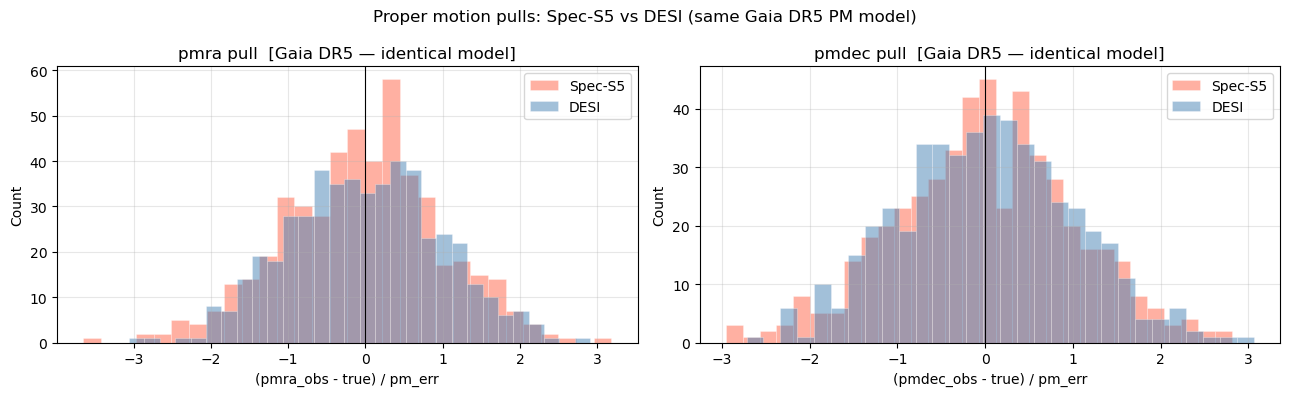

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))

for ax, true_col, obs_key, col_label in [
    (axs[0], obs['pmra'],  'pmra_obs',  'pmra'),
    (axs[1], obs['pmdec'], 'pmdec_obs', 'pmdec'),
]:
    for mock_data, name, color in [
        (mock, 'Spec-S5', 'tomato'),
        (desi,  'DESI',   'steelblue'),
    ]:
        pull = (mock_data[obs_key] - true_col) / mock_data['pm_err']
        finite = np.isfinite(pull)
        ax.hist(pull[finite], bins=30, alpha=0.5, color=color, label=name,
                edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='k', lw=0.8)
    ax.set(xlabel=f'({col_label}_obs - true) / pm_err', ylabel='Count',
           title=f'{col_label} pull  [Gaia DR5 — identical model]')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Proper motion pulls: Spec-S5 vs DESI (same Gaia DR5 PM model)')
plt.tight_layout()
plt.show()


## Comparison: heliocentric distance — true vs observed

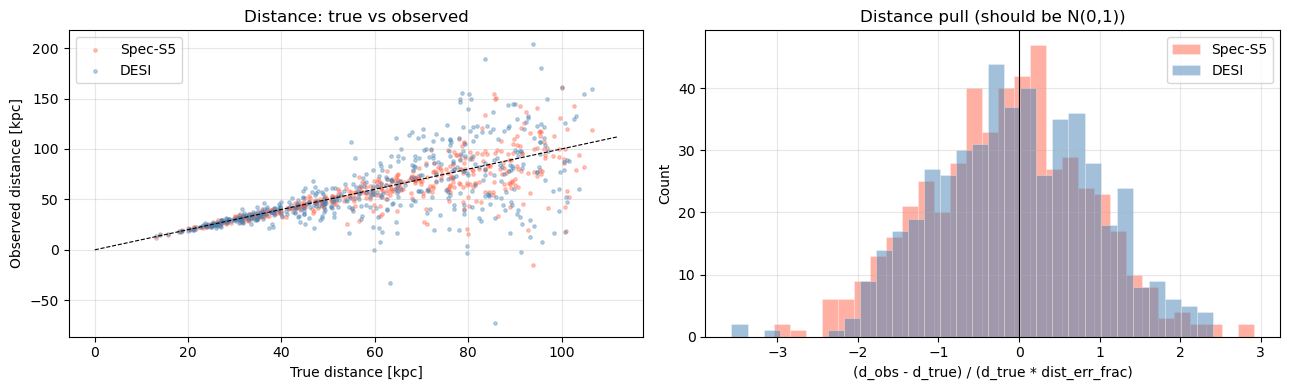

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))

for mock_data, label, color in [
    (mock, 'Spec-S5', 'tomato'),
    (desi,  'DESI',   'steelblue'),
]:
    axs[0].scatter(obs['distance'], mock_data['distance_obs'],
                   s=6, alpha=0.35, color=color, label=label)

lim = [0, obs['distance'].max() * 1.05]
axs[0].plot(lim, lim, 'k--', lw=0.8)
axs[0].set(xlabel='True distance [kpc]', ylabel='Observed distance [kpc]',
           title='Distance: true vs observed')
axs[0].legend(); axs[0].grid(alpha=0.3)

for mock_data, label, color in [
    (mock, 'Spec-S5', 'tomato'),
    (desi,  'DESI',   'steelblue'),
]:
    pull = ((mock_data['distance_obs'] - obs['distance'])
            / (obs['distance'] * mock_data['dist_err_frac']))
    axs[1].hist(pull, bins=30, alpha=0.5, color=color, label=label,
                edgecolor='white', linewidth=0.4)

axs[1].axvline(0, color='k', lw=0.8)
axs[1].set(xlabel='(d_obs - d_true) / (d_true * dist_err_frac)', ylabel='Count',
           title='Distance pull (should be N(0,1))')
axs[1].legend(); axs[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()
